# Distributions, Contours and Everything Else

In [1]:
import numpy as np
np.random.seed(1337)

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
plt.style.use('ggplot')

In [10]:
# generating number of pairs (x, y)
num_bins = 5 # number of bins in each dimension  Try: 5, 20, 50, 500
num_samples = 10000000

data = 100 + 10 * np.random.randn(num_samples, 2) # generate 100000 2-d random data points
joint_probs, edges = np.histogramdd(data, bins=num_bins)

edges = np.array(edges)[:,1:]

In [11]:
print(edges)

[[ 68.76332126  90.28486742 111.80641359 133.32795975 154.84950592]
 [ 68.64546583  89.55060779 110.45574975 131.36089171 152.26603366]]


In [12]:
joint_probs.shape

(5, 5)

In [13]:
joint_probs

array([[4.000000e+00, 1.411000e+03, 6.242000e+03, 1.247000e+03,
        1.000000e+01],
       [1.404000e+03, 2.431400e+05, 1.161297e+06, 2.422860e+05,
        1.368000e+03],
       [6.178000e+03, 1.051699e+06, 5.035414e+06, 1.052780e+06,
        6.243000e+03],
       [1.014000e+03, 1.746220e+05, 8.342140e+05, 1.740550e+05,
        1.001000e+03],
       [2.000000e+00, 6.450000e+02, 3.087000e+03, 6.340000e+02,
        3.000000e+00]])

In [22]:
cut_point = 2

x_vals = np.array(joint_probs[cut_point])
x_vals /= x_vals.sum()

y_vals = np.array([row[cut_point] for row in joint_probs])
y_vals /= y_vals.sum()

print("Cut X and Y on:",cut_point)

Cut X and Y on: 2


In [23]:
print(edges[0])
print(x_vals)
print(y_vals)

[ 68.76332126  90.28486742 111.80641359 133.32795975 154.84950592]
[0.00086378 0.14704318 0.70402586 0.14719432 0.00087286]
[8.86615739e-04 1.64951009e-01 7.15231865e-01 1.18492032e-01
 4.38478498e-04]


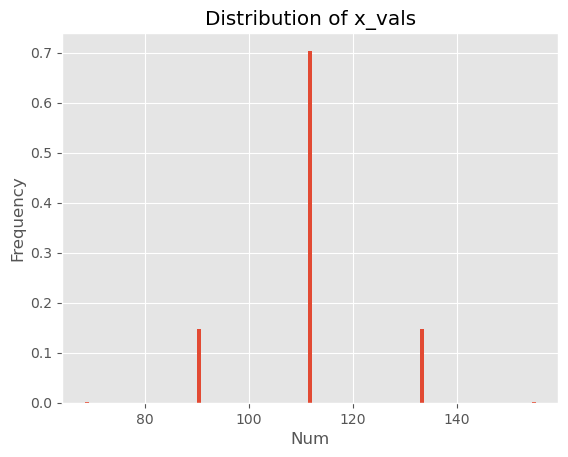

In [24]:
plt.bar(edges[0], x_vals)
plt.ylabel('Frequency')
plt.xlabel('Num')
plt.title("Distribution of x_vals")
plt.show()

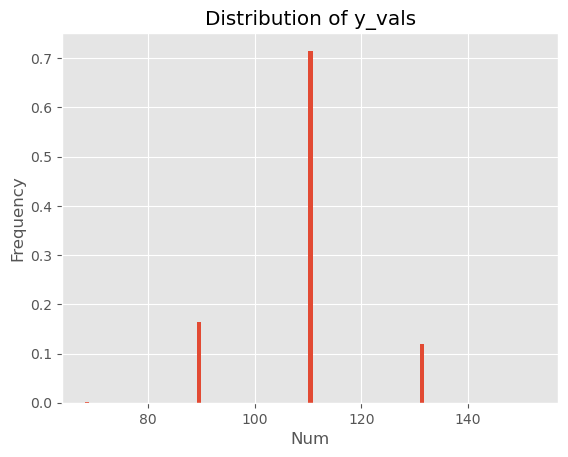

In [25]:
plt.bar(edges[1], y_vals)
plt.ylabel('Frequency')
plt.xlabel('Num')
plt.title("Distribution of y_vals")
plt.show()

In [26]:
x = edges[0]
y = edges[1]
x, y = np.meshgrid(x, y)

z = joint_probs / joint_probs.sum()

Text(0.5, 0, 'Z')

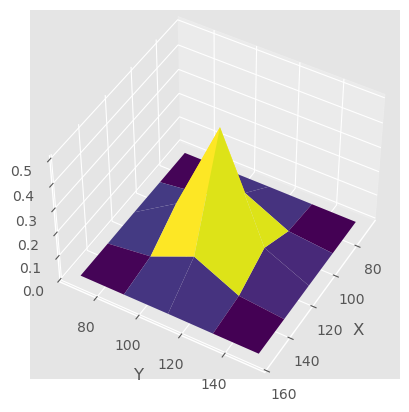

In [27]:
fig = plt.figure()
ax = plt.axes(projection = '3d')

ax.plot_surface(x, y, z, rstride = 1, cstride = 1, cmap = 'viridis')

ax.view_init(45, 30)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

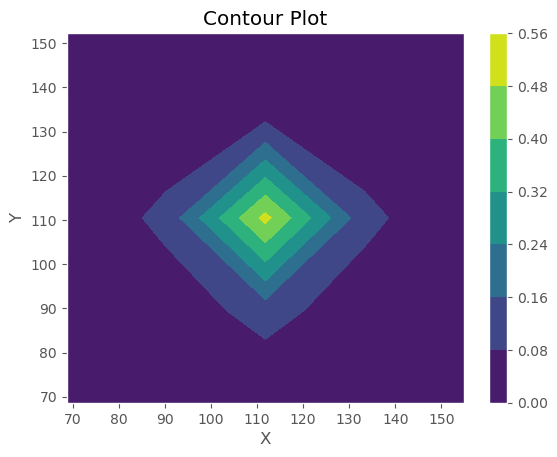

In [28]:
fig, ax = plt.subplots(1, 1)
cp = ax.contourf(x, y, z)
fig.colorbar(cp) # add a colorbar to a plot
ax.set_title('Contour Plot')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()